### Imports

In [1]:
import json
import warnings
from pathlib import Path

import torch
from matplotlib import pyplot as plt

from src.datasets.audio_dataset import AudioDataset
from src.engine import benchmark_cnn, benchmark_snn, get_split_dataloaders
from src.models.cnn_2d_classifier import CNN2DClassifier
from src.models.snn_2d_direct_classifier import SNN2DDirectClassifier
from src.preprocessing import get_cnn_pipeline, get_snn_pipeline
from src.utils import estimate_energy

warnings.filterwarnings("ignore", category=UserWarning)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
CNN_NAME = CNN2DClassifier.NAME
SNN_NAME = SNN2DDirectClassifier.NAME

INPUT_DIR = Path('../../data/audioMNIST')
CNN_MODEL_PATH = Path(f'../../models/{CNN_NAME}.pth')
SNN_MODEL_PATH = Path(f'../../models/{SNN_NAME}.pth')
SNN_HYPERPARAMETERS_PATH = Path(f'../../hyperparameters/{SNN_NAME}.json')

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Chart Functions

In [4]:
# TODO: Move this to utils, for use with second comparison
def plot_accuracy_comparison(ax, model1_acc: float, model2_acc: float) -> None:
    models = [CNN_NAME, SNN_NAME]
    accuracies = [model1_acc, model2_acc]
    colours = ['#4C72B0', '#DD8452']

    bars = ax.bar(models, accuracies, color=colours, width=0.5)
    ax.bar_label(bars, fmt='%.2f%%', padding=4)
    ax.set_title('Model Accuracies')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(95, 100)

def plot_energy_comparison(ax, model1_macs: int, model1_acs: int, model2_macs: int, model2_acs: int) -> None:
    energy1 = estimate_energy(model1_macs, model1_acs)
    energy2 = estimate_energy(model2_macs, model2_acs)

    models = [CNN_NAME, SNN_NAME]
    mac_energies = [energy1['mac_uJ'], energy2['mac_uJ']]
    ac_energies = [energy1['ac_uJ'], energy2['ac_uJ']]

    bars_mac = ax.bar(models, mac_energies, color='#6A4C93', width=0.5, label='MACs')
    bars_ac = ax.bar(models, ac_energies, color='#1982C4', width=0.5, bottom=mac_energies, label='ACs')

    totals = [m + a for m, a in zip(mac_energies, ac_energies)]
    ax.bar_label(bars_ac, labels=[f'{t:.2f} µJ' for t in totals], padding=4)

    ax.set_title('Estimated Energy per Inference')
    ax.set_ylabel('Energy (µJ)')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15) # Just so label at the top doesn't hit the border
    ax.legend()

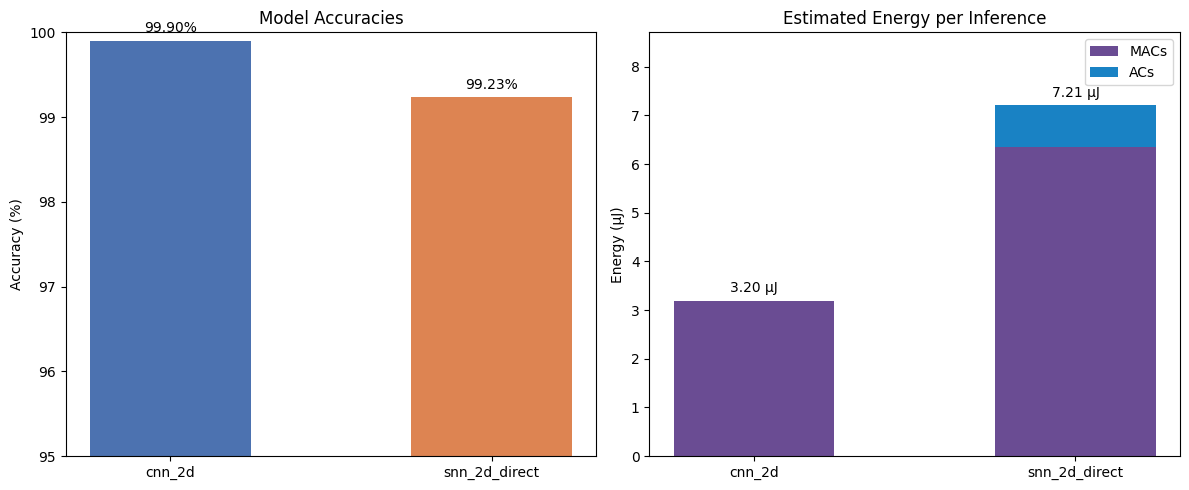

In [5]:
if __name__ == '__main__':
    cnn_dataset = AudioDataset(INPUT_DIR, get_cnn_pipeline())
    snn_dataset = AudioDataset(INPUT_DIR, get_snn_pipeline())

    # Use the same seed for split so that models are tested on exact same things
    _, _, cnn_test_dataloader = get_split_dataloaders(cnn_dataset)
    _, _, snn_test_dataloader = get_split_dataloaders(snn_dataset)

    _, sample_cnn_labels = next(iter(cnn_test_dataloader))
    _, sample_snn_labels = next(iter(snn_test_dataloader))

    assert torch.equal(sample_cnn_labels, sample_snn_labels) # Should fail here immediately, otherwise not a fair test

    # Load CNN
    cnn = CNN2DClassifier().to(device)
    cnn.load_state_dict(torch.load(CNN_MODEL_PATH))

    # Load SNN
    snn_hyperparameters = json.load(open(SNN_HYPERPARAMETERS_PATH, 'r'))[0]['params']
    snn = SNN2DDirectClassifier(beta_init=snn_hyperparameters['beta_init'], slope=snn_hyperparameters['slope'], timesteps=snn_hyperparameters['timesteps']).to(device)
    snn.load_state_dict(torch.load(SNN_MODEL_PATH))

    cnn_acc, cnn_macs = benchmark_cnn(device, cnn, cnn_test_dataloader, leave=False)
    snn_acc, snn_acs, snn_macs = benchmark_snn(device, snn, snn_test_dataloader, direct_encoded=True, leave=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    plot_accuracy_comparison(ax1, cnn_acc, snn_acc)
    plot_energy_comparison(ax2, cnn_macs, 0, snn_macs, snn_acs)
    plt.tight_layout()
    plt.show()

### Training